In [ ]:
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

In [2]:
from loss import CombinedLoss
from model import DeeperSegmentationCNN
from dataset import CerebellumSliceDataset

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

train_dataset = CerebellumSliceDataset(dataset_split="train")
val_dataset = CerebellumSliceDataset(dataset_split="val")

train_loader = DataLoader(dataset=train_dataset, batch_size=4, shuffle=True, num_workers=0)
val_loader = DataLoader(dataset=val_dataset, batch_size=4, shuffle=False, num_workers=0)

cnn = DeeperSegmentationCNN().to(device)
optimizer = optim.Adam(cnn.parameters(), lr=1e-4)
loss_criterion = CombinedLoss(bce_weight=0.5, dice_weight=0.5)

train_loss_history = []
val_loss_history = []
val_dice_history = []
val_iou_history = []

best_val_dice = 0.0
num_epochs = 30

for epoch in range(1, num_epochs + 1):
    cnn.train()
    running_train_loss = 0.0
    
    for images, masks, patients, filenames in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        outputs = cnn(images)
        loss = loss_criterion(outputs, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(cnn.parameters(), max_norm=1.0)
        optimizer.step()
        running_train_loss += loss.item()
    
    avg_epoch_train_loss = running_train_loss / len(train_loader)
    
    cnn.eval()
    running_val_loss = 0.0
    total_tp = 0.0
    total_fp = 0.0
    total_fn = 0.0
    
    with torch.no_grad():
        for val_images, val_masks, patients, filenames in val_loader:
            val_images = val_images.to(device)
            val_masks = val_masks.to(device)
            outputs = cnn(val_images)
            loss = loss_criterion(outputs, val_masks)
            
            binarized_predictions = (outputs > 0.5).float()
            binarized_masks = (val_masks > 0.5).float()
            
            preds_flat = binarized_predictions.view(-1)
            targets_flat = binarized_masks.view(-1)

            total_tp += (preds_flat * targets_flat).sum().item()
            total_fp += (preds_flat * (1.0 - targets_flat)).sum().item()
            total_fn += ((1.0 - preds_flat) * targets_flat).sum().item()
            running_val_loss += loss.item()
    
    avg_epoch_val_loss = running_val_loss / len(val_loader)
    smooth = 1e-6
    val_dice = (2.0 * total_tp + smooth) / (2.0 * total_tp + total_fp + total_fn + smooth)
    val_iou = (total_tp + smooth) / (total_tp + total_fp + total_fn + smooth)
    
    train_loss_history.append(avg_epoch_train_loss)
    val_loss_history.append(avg_epoch_val_loss)
    val_dice_history.append(val_dice)
    val_iou_history.append(val_iou)
    
    print(f"Epoch {epoch} | Train Loss: {avg_epoch_train_loss} | Validation Loss: {avg_epoch_val_loss} | Validation Dice: {val_dice} | Validation IoU: {val_iou}")
    
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(cnn.state_dict(), "best_deeper_cerebellum_model.pth")
        print("Saved new best model checkpoint!")

print(f"Training completed with a final validation Dice Score: {best_val_dice}")

Epoch 1 | Train Loss: 0.47462998343897717 | Validation Loss: 0.4389233956656729 | Validation Dice: 0.6301481649841119 | Validation IoU: 0.4600119143377193
Saved new best model checkpoint!
Epoch 2 | Train Loss: 0.43347650340625216 | Validation Loss: 0.4290814530298424 | Validation Dice: 0.6741489361705337 | Validation IoU: 0.50846505656817
Saved new best model checkpoint!
Epoch 3 | Train Loss: 0.4275074770141925 | Validation Loss: 0.4247227772915115 | Validation Dice: 0.7029641126021778 | Validation IoU: 0.541977380450868
Saved new best model checkpoint!
Epoch 4 | Train Loss: 0.4231593174460743 | Validation Loss: 0.4247281812131405 | Validation Dice: 0.686173435769616 | Validation IoU: 0.5222709408162911
Epoch 5 | Train Loss: 0.42181999795970376 | Validation Loss: 0.4192453018622473 | Validation Dice: 0.7366269199781723 | Validation IoU: 0.5830636504981315
Saved new best model checkpoint!
Epoch 6 | Train Loss: 0.4200390287857902 | Validation Loss: 0.41859551177670556 | Validation Dice: 

In [4]:
import matplotlib.pyplot as plt

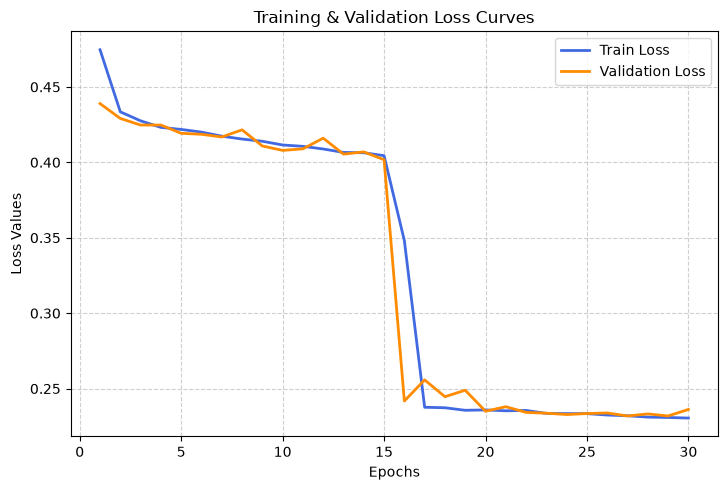

In [5]:
epochs = list(range(1, num_epochs + 1))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(epochs, train_loss_history, label="Train Loss", color="royalblue", linewidth=2)
ax[0].plot(epochs, val_loss_history, label="Validation Loss", color="darkorange", linewidth=2)

ax[0].set_title("Training & Validation Loss Curves")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss Values")
ax[0].legend()
ax[0].grid(True, linestyle="--", alpha=0.6)

ax[1].set_visible(False)

plt.tight_layout()
plt.show()

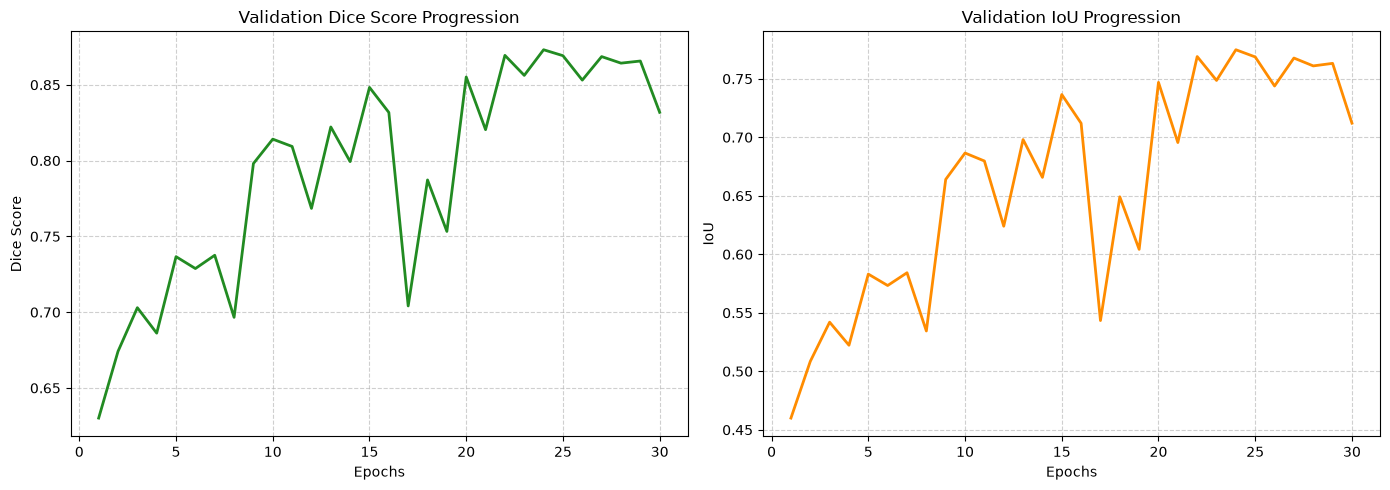

In [6]:
fig, new_ax = plt.subplots(1, 2, figsize=(14, 5))

new_ax[0].plot(epochs, val_dice_history, label="Validation Dice Score", color="forestgreen", linewidth=2)

new_ax[0].set_title("Validation Dice Score Progression")
new_ax[0].set_xlabel("Epochs")
new_ax[0].set_ylabel("Dice Score")
new_ax[0].grid(True, linestyle="--", alpha=0.6)

new_ax[1].set_title("Validation IoU Progression")
new_ax[1].set_xlabel("Epochs")
new_ax[1].set_ylabel("IoU")
new_ax[1].grid(True, linestyle="--", alpha=0.6)
new_ax[1].plot(epochs, val_iou_history, label="Validation IoU", color="darkorange", linewidth=2)


plt.tight_layout()
plt.show()